# Average of each animal variable across THI values

For every integer THI value we compute the **mean of each animal (production / welfare) variable** and plot it against THI.

- THI used: `THI_1_avg` (the test-day THI; consistent with the climate-signal methodology).
- Animal variables: milk yield, ECM, fat %, protein %, somatic cells / SCS, DIM, parity, AFC.
- Data source: `Final_Merged_Data.csv` (test-day records merged with weather indices).

This is a **read-only** analysis notebook — it does not modify any existing file or dataset.

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = '../Thesis_Data/Final_Data/Final_Merged_Data.csv'
THI_COL   = 'THI_1_avg'   # test-day THI

# Candidate animal variables (only those present + non-constant are kept below)
ANIMAL_VARS = ['milk_kg', 'ECM', 'fat_p', 'protein_p', 'cells', 'SCS', 'DIM', 'parity', 'AFC']

# Readable labels for the plots
LABELS = {
    'milk_kg':   'Milk yield (kg)',
    'ECM':       'Energy-corrected milk (kg)',
    'fat_p':     'Fat %',
    'protein_p': 'Protein %',
    'cells':     'Somatic cell count (x1000/mL)',
    'SCS':       'Somatic cell score',
    'DIM':       'Days in milk',
    'parity':    'Parity',
    'AFC':       'Age at first calving',
}

In [97]:
# Load only the columns we need (file is large)
usecols = [THI_COL] + ANIMAL_VARS
df = pd.read_csv(DATA_PATH, usecols=lambda c: c in usecols)

# Coerce every column to numeric. Some columns (e.g. AFC) are stored as
# strings like '1824 days' -> extract the numeric part before converting.
df[THI_COL] = pd.to_numeric(df[THI_COL], errors='coerce')
for v in [c for c in ANIMAL_VARS if c in df.columns]:
    if df[v].dtype == object:
        df[v] = pd.to_numeric(
            df[v].astype(str).str.extract(r'(-?\d+\.?\d*)')[0], errors='coerce'
        )
    else:
        df[v] = pd.to_numeric(df[v], errors='coerce')

# Keep only variables that are present, numeric, and vary (drop constants such as NM)
vars_present = [v for v in ANIMAL_VARS if v in df.columns and df[v].nunique(dropna=True) > 1]
dropped = [v for v in ANIMAL_VARS if v not in vars_present]

print(f'Records loaded: {len(df):,}')
print(f'THI range     : {df[THI_COL].min():.1f} to {df[THI_COL].max():.1f}')
print(f'Animal vars   : {vars_present}')
if dropped:
    print(f'Dropped (missing/constant): {dropped}')

Records loaded: 1,631,410
THI range     : 29.3 to 81.0
Animal vars   : ['milk_kg', 'ECM', 'fat_p', 'protein_p', 'cells', 'SCS', 'DIM', 'parity', 'AFC']


In [98]:
# Bin THI to integer values and average each animal variable per THI value
df = df.dropna(subset=[THI_COL]).copy()
df['THI_bin'] = df[THI_COL].round().astype(int)

grp = df.groupby('THI_bin')
means  = grp[vars_present].mean()
counts = grp.size().rename('n')

# Ignore sparsely-populated THI values (unstable means)
MIN_N = 30
valid = counts[counts >= MIN_N].index
means  = means.loc[valid]
counts = counts.loc[valid]

summary = means.join(counts)
summary.head(10)

,milk_kg,ECM,fat_p,protein_p,cells,SCS,DIM,parity,AFC,n
THI_bin,,,,,,,,,,
29,10.953125,19.687667,9.329792,4.729271,132.229167,2.725888,151.739583,2.947917,2074.270833,96
30,8.333526,14.649514,9.064740,4.956647,315.479769,3.980871,157.416185,2.127168,1519.000000,173
31,9.010035,14.901409,8.289031,4.737543,295.875433,3.625018,145.474048,1.979239,1567.214533,289
32,8.351429,14.396774,8.893524,4.639905,512.933333,4.511765,149.857143,2.647619,1919.647619,105
33,9.420871,15.211521,8.016754,4.745448,598.866064,4.059755,136.545604,2.763353,1914.114309,1217
34,9.269989,15.709163,8.640895,4.789230,349.332956,3.631234,152.249151,2.702152,1879.329558,883
35,7.886443,13.553415,8.886862,4.792567,449.412034,3.988434,154.852247,3.049505,1926.107388,1313
36,8.149252,13.937274,8.830765,4.781887,375.959148,3.621442,147.018412,2.314154,1620.591484,1738
37,8.945578,14.799644,8.340098,4.755121,401.331445,3.842425,150.589865,2.614416,1810.458268,3177


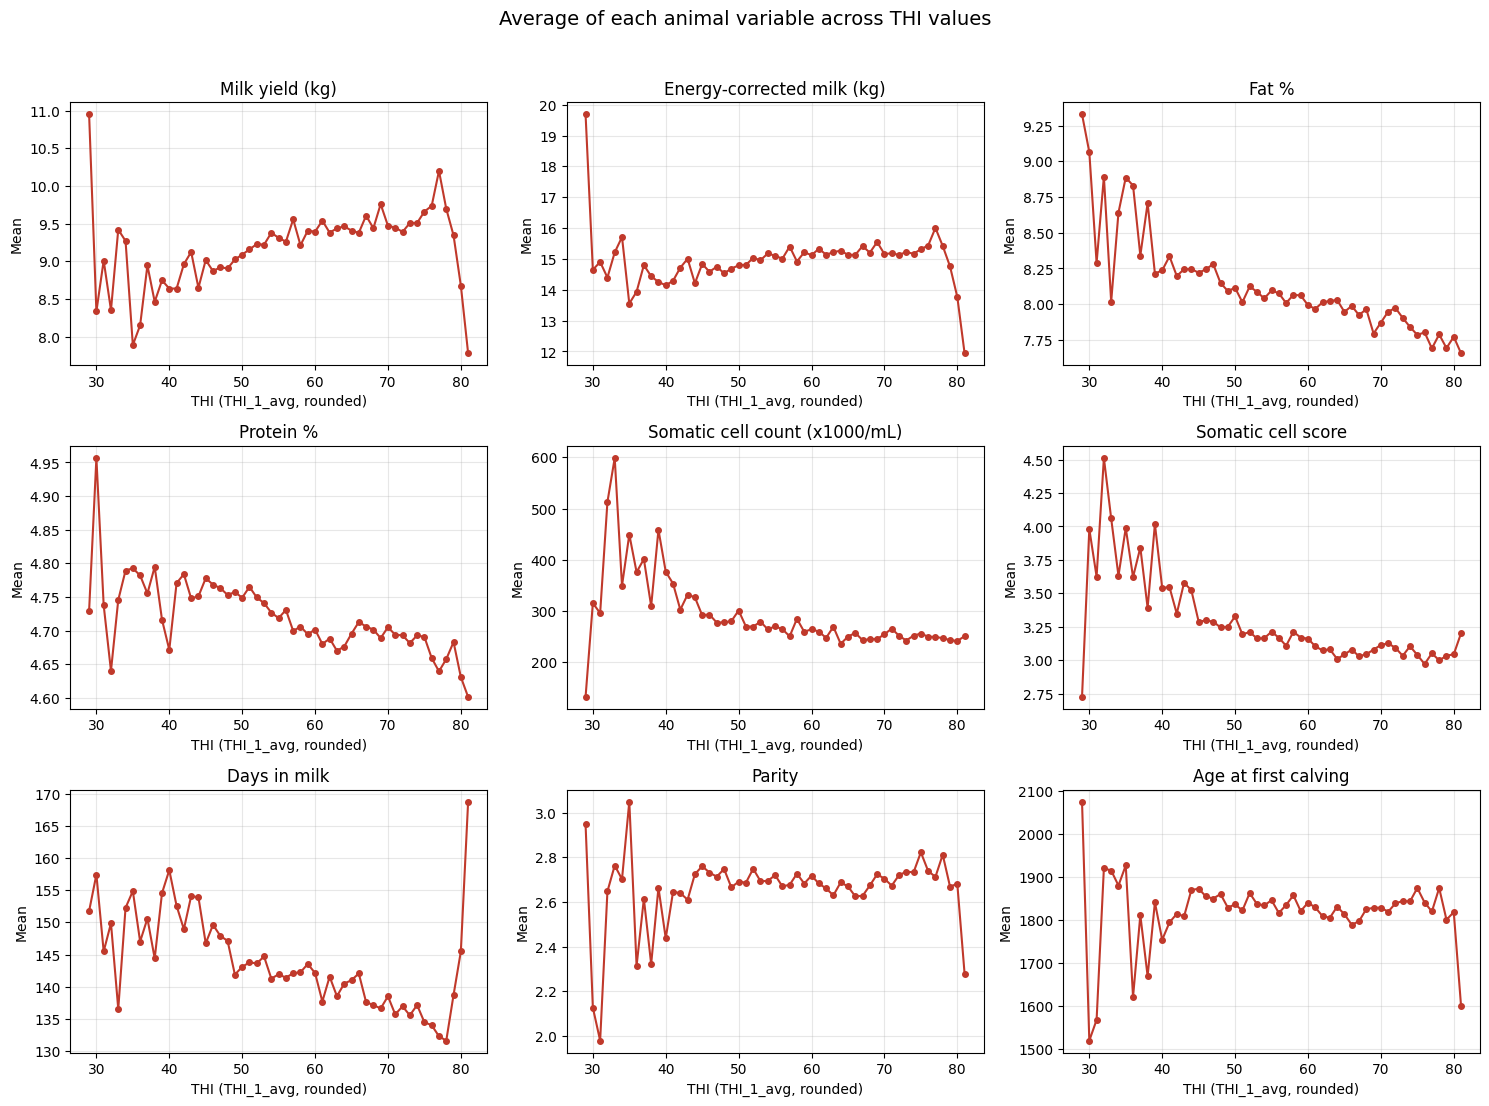

In [99]:
# One subplot per animal variable: mean(variable) vs THI
n = len(vars_present)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.6 * nrows), squeeze=False)
axes = axes.ravel()

for ax, var in zip(axes, vars_present):
    ax.plot(means.index, means[var], marker='o', ms=4, lw=1.5, color='#c0392b')
    ax.set_title(LABELS.get(var, var))
    ax.set_xlabel('THI (THI_1_avg, rounded)')
    ax.set_ylabel('Mean')
    ax.grid(alpha=0.3)

# Hide any unused axes
for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle('Average of each animal variable across THI values', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

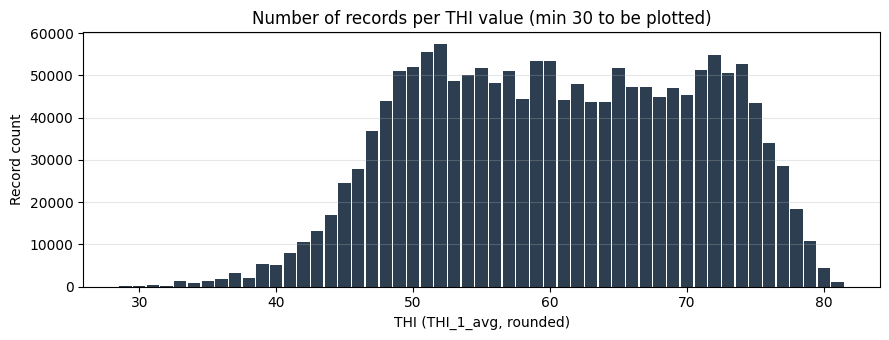

In [100]:
# Context: how many test-day records fall at each THI value
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(counts.index, counts.values, color='#2c3e50', width=0.9)
ax.set_title(f'Number of records per THI value (min {MIN_N} to be plotted)')
ax.set_xlabel('THI (THI_1_avg, rounded)')
ax.set_ylabel('Record count')
ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
plt.show()

---
## Best THI range for each variable

For every production / welfare variable we identify the THI range in which it is at its **optimum**:

- **Higher is better** — `milk_kg`, `ECM`, `fat_p`, `protein_p` (yield and milk-quality traits).
- **Lower is better** — `cells` (SCC) and `SCS` (udder health / welfare).

Method:
1. Restrict to **reliably-populated THI values** (≥ 5 000 records per THI unit) so the optimum is not driven by noisy sparse tails.
2. Smooth the per-THI means with a count-weighted 3-unit rolling window.
3. The optimum is the THI at the peak (max) or trough (min). The **best range** is the contiguous THI band that stays within **10 % of the optimum** (measured on the curve's span) around that point.

> ⚠️ **Interpret as descriptive, not causal.** These are *raw marginal* averages, so THI is confounded with season and lactation stage. That confound shows up directly here: milk/ECM appear to "peak" at THI ≈ 77 and SCC/SCS look *lowest* at high THI — the opposite of a heat-stress response — because high-THI test days are summer records with a different DIM/parity mix. For the causal thermal-comfort zone, use the **THI-anomaly** approach in `Climate_Signal_Validation.ipynb`, not these marginal optima.


In [101]:
# --- Best THI range per variable ---------------------------------------------
# Direction of "better": max -> higher is better, min -> lower is better.
VAR_DIRECTION = {
    'milk_kg': 'max', 'ECM': 'max', 'fat_p': 'max', 'protein_p': 'max',
    'cells': 'min', 'SCS': 'min',
}
RELIABLE_N = 5000   # min records per THI unit to be trusted for the optimum
BAND_FRAC  = 0.10   # "best" = within 10% of the optimum, on the curve's span
SMOOTH_WIN = 3      # count-weighted rolling window (in THI units)

# Reliable subset of the per-THI means (means/counts come from the cell above)
rel = counts[counts >= RELIABLE_N].index
m_rel, w_rel = means.loc[rel], counts.loc[rel]
analysis_vars = [v for v in vars_present if v in VAR_DIRECTION]

# Count-weighted rolling smooth
smooth = pd.DataFrame(index=m_rel.index)
for v in analysis_vars:
    num = (m_rel[v] * w_rel).rolling(SMOOTH_WIN, center=True, min_periods=1).sum()
    den = w_rel.rolling(SMOOTH_WIN, center=True, min_periods=1).sum()
    smooth[v] = num / den

def contiguous_band(mask, center):
    """Longest run of consecutive-integer THI values that are True and include `center`."""
    c = center
    while (c - 1) in mask.index and bool(mask.get(c - 1, False)):
        c -= 1
    lo = c
    c = center
    while (c + 1) in mask.index and bool(mask.get(c + 1, False)):
        c += 1
    return lo, c

rows, best_ranges = [], {}
for v in analysis_vars:
    s = smooth[v].dropna()
    vmax, vmin = s.max(), s.min()
    span = vmax - vmin
    if VAR_DIRECTION[v] == 'max':
        opt = int(s.idxmax()); opt_val = vmax; mask = s >= (vmax - BAND_FRAC * span)
    else:
        opt = int(s.idxmin()); opt_val = vmin; mask = s <= (vmin + BAND_FRAC * span)
    lo, hi = contiguous_band(mask, opt)
    best_ranges[v] = (lo, hi, opt)
    rows.append({
        'variable':       v,
        'better':         VAR_DIRECTION[v],
        'best_THI_range': f'{lo}–{hi}',
        'optimum_THI':    opt,
        'optimum_value':  round(float(opt_val), 3),
        'worst_value':    round(float(vmin if VAR_DIRECTION[v] == 'max' else vmax), 3),
        'records_in_range': int(counts.loc[lo:hi].sum()),
    })

best_df = pd.DataFrame(rows).set_index('variable')
print(f'Reliable THI window (>= {RELIABLE_N} rec/unit): '
      f'{m_rel.index.min()} to {m_rel.index.max()}')
best_df


Reliable THI window (>= 5000 rec/unit): 39 to 79


,better,best_THI_range,optimum_THI,optimum_value,worst_value,records_in_range
variable,,,,,,
milk_kg,max,76–78,77,9.892,8.669,80824
ECM,max,76–78,77,15.633,14.201,80824
fat_p,max,39–47,40,8.272,7.721,147903
protein_p,max,42–48,46,4.769,4.652,173372
cells,min,60–79,68,244.489,418.271,860104
SCS,min,73–79,77,3.007,3.783,238075


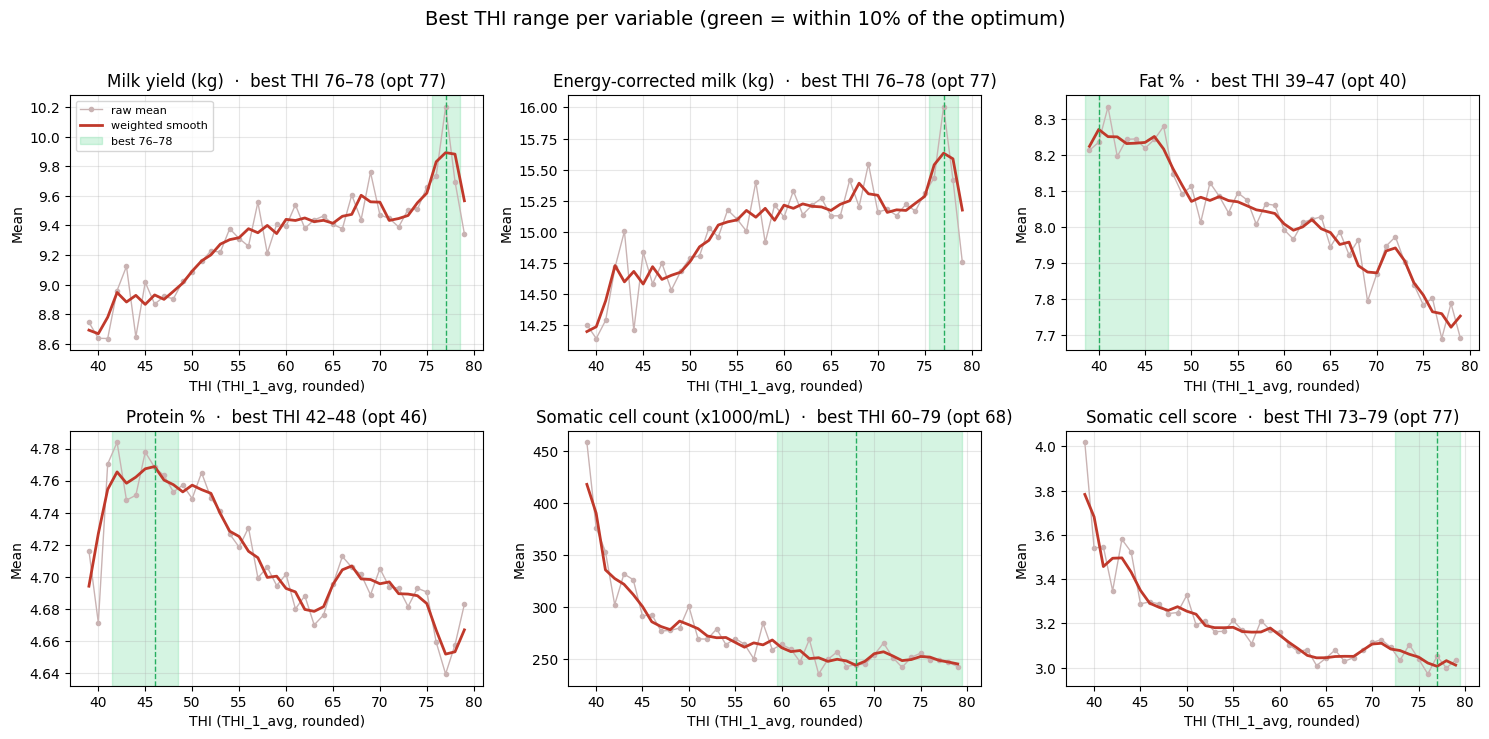

In [102]:
# Plot each variable with its best THI range shaded (green) and optimum marked
n = len(analysis_vars)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.6 * nrows), squeeze=False)
axes = axes.ravel()

for ax, v in zip(axes, analysis_vars):
    lo, hi, opt = best_ranges[v]
    ax.plot(m_rel.index, m_rel[v], color='#c9b3b3', lw=1, marker='o', ms=3, label='raw mean')
    ax.plot(smooth.index, smooth[v], color='#c0392b', lw=2, label='weighted smooth')
    ax.axvspan(lo - 0.5, hi + 0.5, color='#2ecc71', alpha=0.20, label=f'best {lo}–{hi}')
    ax.axvline(opt, color='#27ae60', ls='--', lw=1)
    ax.set_title(f'{LABELS.get(v, v)}  ·  best THI {lo}–{hi} (opt {opt})')
    ax.set_xlabel('THI (THI_1_avg, rounded)')
    ax.set_ylabel('Mean')
    ax.grid(alpha=0.3)

axes[0].legend(fontsize=8, loc='best')
for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle('Best THI range per variable (green = within 10% of the optimum)',
             fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


---
## Deseasonalized version — best **THI-anomaly** range (causal)

The ranges above are confounded by season. Here we repeat the analysis on the **deseasonalized** signal, following the methodology in `Climate_Signal_Validation.ipynb`:

- **x-axis = THI anomaly** = `THI_1_avg − (farm × calendar-month mean)`. Positive = *hotter than normal for that farm and month*; negative = cooler than normal. This removes the season/geography confound.
- **y-axis = within-animal trait deviation** = trait − that animal's own mean. This removes animal- and farm-level confounds (genetics, herd, lactation number).

So the "best anomaly range" is the amount of heat-above-normal at which each trait is at its optimum, holding season and animal fixed. If the confound explanation is right, the optima should **flip sign** versus the raw table — the best conditions should be at *negative* anomaly (cooler than normal), and heat-above-normal should be worst.


In [103]:
# --- Deseasonalized: best THI-anomaly range per variable ---------------------
# Reuses VAR_DIRECTION, RELIABLE_N, BAND_FRAC, SMOOTH_WIN, contiguous_band,
# analysis_vars and best_df from the cells above.

# Reload with the keys needed to build the anomaly (farm, animal, date)
anom_cols = ['Farm_Code', 'Animal_ID', 'dtt', THI_COL] + analysis_vars
da = pd.read_csv(DATA_PATH, usecols=lambda c: c in anom_cols)
da['dtt']   = pd.to_datetime(da['dtt'], format='mixed', errors='coerce')
da['month'] = da['dtt'].dt.month
da[THI_COL] = pd.to_numeric(da[THI_COL], errors='coerce')
for v in analysis_vars:
    da[v] = pd.to_numeric(da[v], errors='coerce')
da = da.dropna(subset=[THI_COL, 'Farm_Code', 'Animal_ID', 'month'])

# THI anomaly = heat above the farm-month normal (deseasonalized)
da['thi_anom'] = da[THI_COL] - da.groupby(['Farm_Code', 'month'])[THI_COL].transform('mean')
# within-animal trait deviation (removes animal/farm-level confounds)
for v in analysis_vars:
    da[v + '_wa'] = da[v] - da.groupby('Animal_ID')[v].transform('mean')

# Bin the anomaly to integer THI-units and average the within-animal deviations
da['anom_bin'] = da['thi_anom'].round().astype(int)
ag = da.groupby('anom_bin')
a_means  = ag[[v + '_wa' for v in analysis_vars]].mean()
a_counts = ag.size()
arel = a_counts[a_counts >= RELIABLE_N].index
a_means, a_w = a_means.loc[arel], a_counts.loc[arel]

# Count-weighted smooth
a_smooth = pd.DataFrame(index=a_means.index)
for v in analysis_vars:
    col = v + '_wa'
    num = (a_means[col] * a_w).rolling(SMOOTH_WIN, center=True, min_periods=1).sum()
    den = a_w.rolling(SMOOTH_WIN, center=True, min_periods=1).sum()
    a_smooth[v] = num / den

a_rows, a_best = [], {}
for v in analysis_vars:
    s = a_smooth[v].dropna()
    vmax, vmin = s.max(), s.min()
    span = vmax - vmin
    if VAR_DIRECTION[v] == 'max':
        opt = int(s.idxmax()); mask = s >= (vmax - BAND_FRAC * span)
    else:
        opt = int(s.idxmin()); mask = s <= (vmin + BAND_FRAC * span)
    lo, hi = contiguous_band(mask, opt)
    a_best[v] = (lo, hi, opt)
    a_rows.append({
        'variable':           v,
        'better':             VAR_DIRECTION[v],
        'best_anomaly_range': f'{lo:+d}..{hi:+d}',
        'optimum_anomaly':    opt,
    })
anom_df = pd.DataFrame(a_rows).set_index('variable')
print(f'Reliable anomaly window: {a_means.index.min():+d} to {a_means.index.max():+d} '
      f'THI units vs the farm-month normal')

# Side-by-side comparison: confounded (raw) vs deseasonalized (anomaly) optima
comparison = best_df[['best_THI_range', 'optimum_THI']].join(
    anom_df[['best_anomaly_range', 'optimum_anomaly']]
)
comparison


Reliable anomaly window: -9 to +8 THI units vs the farm-month normal


,best_THI_range,optimum_THI,best_anomaly_range,optimum_anomaly
variable,,,,
milk_kg,76–78,77,-7..-6,-6
ECM,76–78,77,-7..-5,-6
fat_p,39–47,40,-9..-9,-9
protein_p,42–48,46,-6..-6,-6
cells,60–79,68,-9..-9,-9
SCS,73–79,77,-9..-9,-9


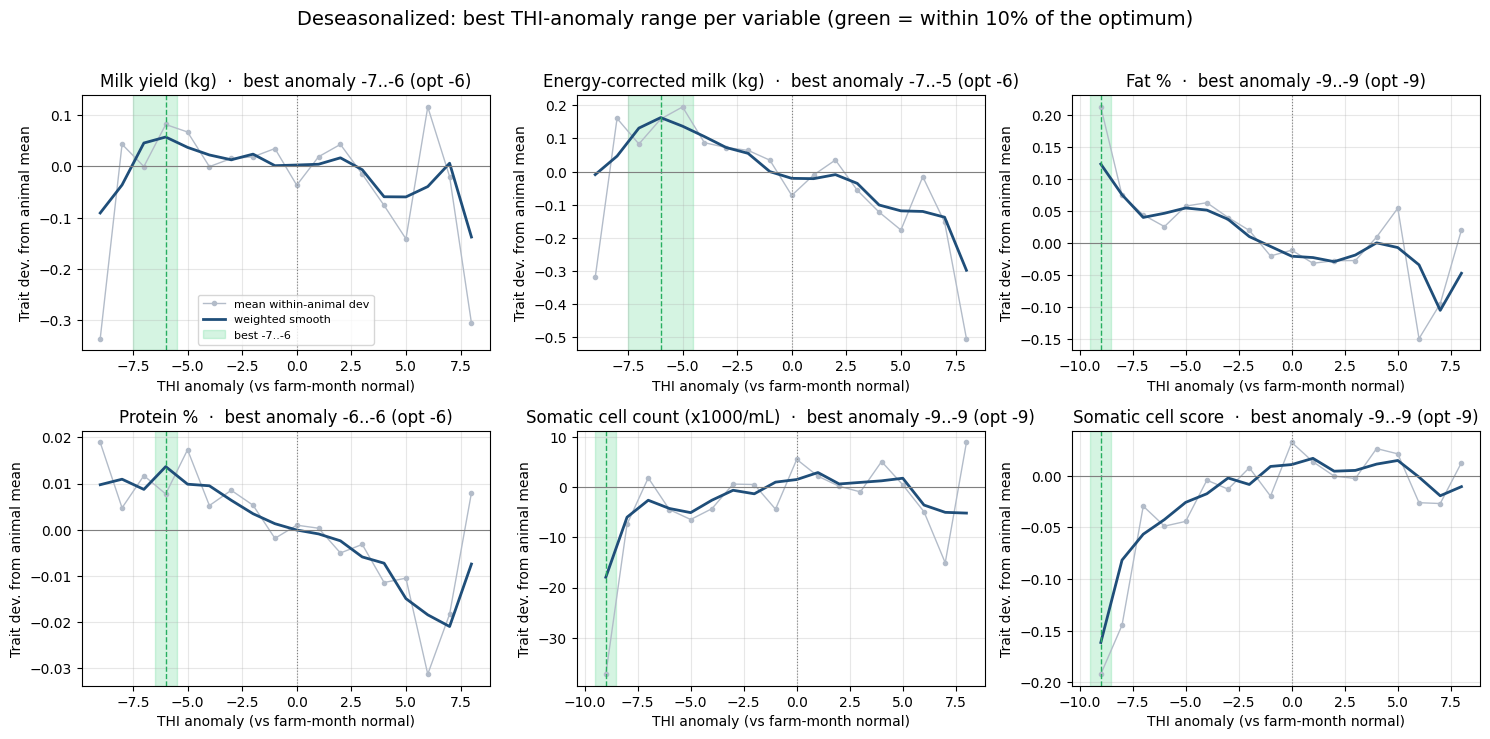

In [104]:
# Plot within-animal trait deviation vs THI anomaly, with best band shaded.
# Anomaly 0 (grey line) = the farm-month normal; left of it = cooler than normal.
n = len(analysis_vars)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.6 * nrows), squeeze=False)
axes = axes.ravel()

for ax, v in zip(axes, analysis_vars):
    lo, hi, opt = a_best[v]
    ax.plot(a_means.index, a_means[v + '_wa'], color='#b3bcc9', lw=1, marker='o', ms=3,
            label='mean within-animal dev')
    ax.plot(a_smooth.index, a_smooth[v], color='#1f4e79', lw=2, label='weighted smooth')
    ax.axvspan(lo - 0.5, hi + 0.5, color='#2ecc71', alpha=0.20, label=f'best {lo:+d}..{hi:+d}')
    ax.axvline(opt, color='#27ae60', ls='--', lw=1)
    ax.axhline(0, color='gray', lw=0.8)
    ax.axvline(0, color='gray', lw=0.8, ls=':')
    ax.set_title(f'{LABELS.get(v, v)}  ·  best anomaly {lo:+d}..{hi:+d} (opt {opt:+d})')
    ax.set_xlabel('THI anomaly (vs farm-month normal)')
    ax.set_ylabel('Trait dev. from animal mean')
    ax.grid(alpha=0.3)

axes[0].legend(fontsize=8, loc='best')
for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle('Deseasonalized: best THI-anomaly range per variable '
             '(green = within 10% of the optimum)', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


---
## Region-stratified — best **absolute** THI range per variable (North / Central / South)

Because the normal THI differs by region (North ≈ 56, Central/South ≈ 61), we recompute the best **absolute** THI range *separately within each macro-area*, to see whether the optimum THI shifts — i.e. whether southern buffaloes are acclimatised to higher heat.

- Regions are grouped into the standard Italian macro-areas (ISTAT): **North** (Piemonte, Lombardia, Veneto, Friuli, Emilia Romagna), **Central** (Toscana, Umbria, Marche, Lazio), **South & Islands** (Abruzzo, Molise, Campania, Basilicata, Puglia, Calabria, Sicilia).
- Each region is trimmed to its own 1st–99th THI percentile (the North genuinely has few hot days) and to THI units with ≥ 1 500 records.
- Same optimisation rule as before (peak/trough, 10% band). Dotted vertical lines on the plot mark each region's **normal THI**.

> ⚠️ Still **descriptive**: within each region THI remains season-confounded, so the *level* of each curve reflects herd/management as much as climate. The comparable signal across regions is the **shape / where the curve turns**, not the absolute height. For a clean acclimatisation test, compare the per-region within-animal heat *slope* (anomaly method) — see the note after the plot.


In [105]:
# --- Region-stratified: best ABSOLUTE THI range per variable -----------------
# Reuses analysis_vars, VAR_DIRECTION, BAND_FRAC, SMOOTH_WIN, contiguous_band, LABELS.
MACRO_AREA = {
    'Piemonte': 'North', 'Lombardia': 'North', 'Veneto': 'North',
    'Friuli Venezia Giulia': 'North', 'Emilia Romagna': 'North',
    'Toscana': 'Central', 'Umbria': 'Central', 'Marche': 'Central', 'Lazio': 'Central',
    'Abruzzo': 'South', 'Molise': 'South', 'Campania': 'South', 'Basilicata': 'South',
    'Puglia': 'South', 'Calabria': 'South', 'Sicilia': 'South',
}
REGION_FLOOR = 1500   # min records per THI unit within a region
AREAS = ['North', 'Central', 'South']

reg = pd.read_csv(DATA_PATH, usecols=lambda c: c in ['Region', THI_COL] + analysis_vars)
reg[THI_COL] = pd.to_numeric(reg[THI_COL], errors='coerce')
for v in analysis_vars:
    reg[v] = pd.to_numeric(reg[v], errors='coerce')
reg['Area'] = reg['Region'].map(MACRO_AREA)
reg = reg.dropna(subset=[THI_COL, 'Area'])

region_best, region_curves, region_normal = {}, {}, {}
for area in AREAS:
    d = reg[reg['Area'] == area]
    region_normal[area] = d[THI_COL].mean()
    q1, q99 = d[THI_COL].quantile([0.01, 0.99])          # trim this region's own sparse tails
    d = d[(d[THI_COL] >= q1) & (d[THI_COL] <= q99)]
    g = d.groupby(d[THI_COL].round().astype(int))
    m, cnt = g[analysis_vars].mean(), g.size()
    keep = cnt[cnt >= REGION_FLOOR].index
    m, w = m.loc[keep], cnt.loc[keep]
    for v in analysis_vars:
        num = (m[v] * w).rolling(SMOOTH_WIN, center=True, min_periods=1).sum()
        den = w.rolling(SMOOTH_WIN, center=True, min_periods=1).sum()
        s = (num / den).dropna()
        region_curves[(area, v)] = s
        vmax, vmin = s.max(), s.min()
        span = vmax - vmin
        if VAR_DIRECTION[v] == 'max':
            opt = int(s.idxmax()); mask = s >= (vmax - BAND_FRAC * span)
        else:
            opt = int(s.idxmin()); mask = s <= (vmin + BAND_FRAC * span)
        lo, hi = contiguous_band(mask, opt)
        region_best[(area, v)] = (lo, hi, opt)

print('Region normal (mean) THI:', {a: round(region_normal[a], 1) for a in AREAS})
region_tbl = pd.DataFrame(
    {area: [f"{region_best[(area, v)][0]}–{region_best[(area, v)][1]} "
            f"(opt {region_best[(area, v)][2]})" for v in analysis_vars]
     for area in AREAS},
    index=analysis_vars,
)
region_tbl.index.name = 'variable'
region_tbl


Region normal (mean) THI: {'North': np.float64(55.8), 'Central': np.float64(61.4), 'South': np.float64(60.9)}


,North,Central,South
variable,,,
milk_kg,76–76 (opt 76),78–78 (opt 78),76–78 (opt 77)
ECM,76–76 (opt 76),78–78 (opt 78),77–78 (opt 77)
fat_p,49–49 (opt 49),44–46 (opt 44),43–47 (opt 46)
protein_p,50–50 (opt 50),44–44 (opt 44),42–43 (opt 42)
cells,63–64 (opt 63),69–70 (opt 70),76–78 (opt 78)
SCS,63–64 (opt 63),62–67 (opt 66),76–78 (opt 77)


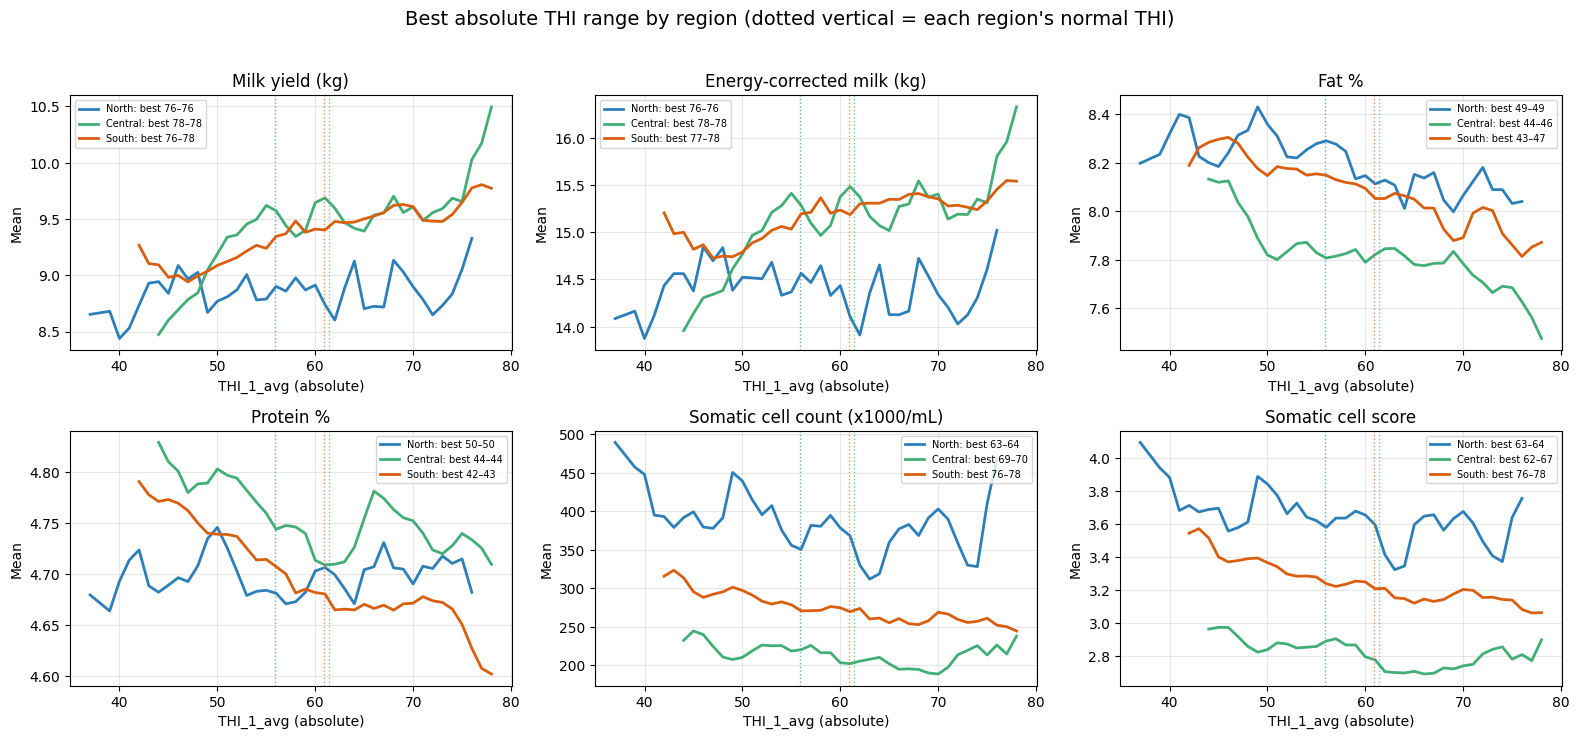

In [106]:
# Overlay the three regions per variable; dotted line = each region's normal THI
AREA_COLOR = {'North': '#2c7fb8', 'Central': '#41ae76', 'South': '#d95f0e'}
n = len(analysis_vars)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.3 * ncols, 3.6 * nrows), squeeze=False)
axes = axes.ravel()

for ax, v in zip(axes, analysis_vars):
    for area in AREAS:
        s = region_curves[(area, v)]
        lo, hi, opt = region_best[(area, v)]
        ax.plot(s.index, s.values, color=AREA_COLOR[area], lw=2, label=f'{area}: best {lo}–{hi}')
        ax.axvline(region_normal[area], color=AREA_COLOR[area], ls=':', lw=1, alpha=0.7)
    ax.set_title(LABELS.get(v, v))
    ax.set_xlabel('THI_1_avg (absolute)')
    ax.set_ylabel('Mean')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle("Best absolute THI range by region "
             "(dotted vertical = each region's normal THI)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


---
## Per-region heat-sensitivity metric — cluster-curve + parity controlled

Each region is reduced to **one causal number per trait**: the within-animal effect of heat *above the farm-month normal*, controlling for lactation stage with **cluster-specific lactation curves** (not a global DIM polynomial) plus parity:

$$(\text{trait}-\overline{\text{trait}}_{animal}) \sim (\text{thi\_anom}-\overline{\text{thi\_anom}}_{animal}) + \text{cc} + \text{parity}$$

where **`cc`** = expected milk at that DIM for the animal's own **lactation-curve cluster**. Lactations (`Animal_ID × parity`) are grouped into 3 curve-shape clusters, and each cluster supplies its own DIM curve — a fairer control than forcing one shape on every animal. Scaled to **Δ per +10 THI above the farm-month normal**, SE clustered on `Animal_ID`.

- Sign: milk/ECM/fat/protein **negative** = trait drops under heat; SCC/SCS **positive** = udder health worsens. Magnitude = heat-sensitivity; near 0 = effectively unaffected.
- The cell below also plots the 3 cluster curves it uses.
- A **Heat-Vulnerability Index** (z(milk loss) + z(SCS gain)) ranks reliable regions on one scale; regions with < 500 animals are unstable and listed separately.


Cluster-curve + parity controlled — Δ trait per +10 THI above the farm-month normal.
records: 1,631,410 | 3 lactation-curve clusters | 76% of records have a cluster

National reference:
      n  n_animals  milk_kg    ECM  fat_p  protein_p  cells    SCS
1631410      90532   -0.032 -0.175 -0.089     -0.021 -5.819 -0.018

Reliable regions (n_animals >= 500) ranked by Heat-Vulnerability Index:
               Region  n_animals  milk_kg    ECM  fat_p  protein_p   cells    SCS    HVI
               Veneto       1095   -0.187 -0.373 -0.055     -0.049  29.815  0.184  2.389
             Calabria       1744   -0.129 -0.372 -0.117     -0.026  49.630  0.127  1.303
             Piemonte       2108   -0.231 -0.513 -0.119     -0.050  -4.240 -0.011  1.143
            Lombardia       2668   -0.154 -0.445 -0.130     -0.011  -1.242 -0.019  0.295
               Puglia       3219   -0.149 -0.306 -0.022     -0.021  -4.220 -0.019  0.250
              Sicilia        864   -0.266 -0.656 -0.120     -0.056 -92.66

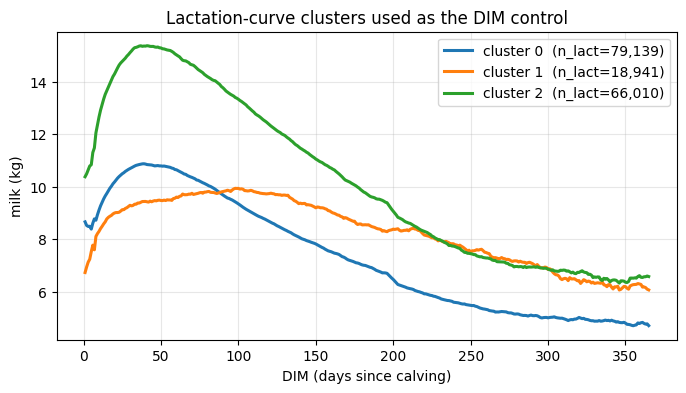

In [107]:
# --- Per-region heat effect, lactation stage controlled by CLUSTER-SPECIFIC curves ---
# Lactation stage is controlled with each lactation's own curve-cluster curve (cc) rather
# than a global DIM polynomial. Model per region/trait (all within-animal):
#   (trait - animal mean) ~ (thi_anom - animal mean) + cc + parity
# cc = expected milk at that DIM for the animal's lactation-curve cluster.
# Coefficient on THI-anomaly = heat effect, per +10 THI above the farm-month normal;
# SE cluster-robust on Animal_ID.
from math import erf, sqrt

N_ANIMALS_MIN = 500   # regions below this are shown but not ranked
K_CURVE = 3           # number of lactation-curve clusters

# 1) Load traits + keys + lactation-stage fields
sc = pd.read_csv(DATA_PATH, usecols=lambda c: c in
                 ['Region', 'Farm_Code', 'Animal_ID', 'dtt', 'parity', 'DIM', THI_COL] + analysis_vars)
sc['dtt']   = pd.to_datetime(sc['dtt'], format='mixed', errors='coerce')
sc['month'] = sc['dtt'].dt.month
for c in ['parity', 'DIM', THI_COL] + analysis_vars:
    sc[c] = pd.to_numeric(sc[c], errors='coerce')
sc = sc.dropna(subset=[THI_COL, 'DIM', 'parity', 'Region', 'Farm_Code', 'Animal_ID', 'month', 'milk_kg'])
sc = sc[(sc['milk_kg'] > 0) & (sc['DIM'].between(1, 365))]
sc['lact_id'] = sc['Animal_ID'].astype(str) + '_p' + sc['parity'].astype(int).astype(str)

# 2) Cluster lactations by curve shape (one lactation = animal x parity)
gl = sc.groupby('lact_id')
feat = gl.agg(peak_yield=('milk_kg', lambda x: x.quantile(.95)), mean_yield=('milk_kg', 'mean'),
              dmin=('DIM', 'min'), dmax=('DIM', 'max'), nrec=('DIM', 'size'))
feat['peak_DIM'] = sc.loc[gl['milk_kg'].idxmax(), ['lact_id', 'DIM']].set_index('lact_id')['DIM']
feat['persist']  = sc[sc['DIM'].between(200, 305)].groupby('lact_id')['milk_kg'].mean() / feat['peak_yield']
usable = feat[(feat.nrec >= 4) & (feat.dmin <= 60) & (feat.dmax >= 200) & feat.persist.notna()].copy()
FEATS = ['peak_DIM', 'peak_yield', 'persist', 'mean_yield']
Xraw = usable[FEATS].values.astype(float)
Xc = (Xraw - Xraw.mean(0)) / Xraw.std(0)
try:
    from sklearn.cluster import KMeans
    labels = KMeans(K_CURVE, random_state=0, n_init=10).fit_predict(Xc)
except Exception:                                   # numpy KMeans fallback (same result)
    rng = np.random.default_rng(0)
    Ck = Xc[rng.choice(len(Xc), K_CURVE, replace=False)]
    for _ in range(50):
        labels = ((Xc[:, None, :] - Ck[None]) ** 2).sum(2).argmin(1)
        newC = np.array([Xc[labels == j].mean(0) if (labels == j).any() else Ck[j] for j in range(K_CURVE)])
        if np.allclose(newC, Ck):
            break
        Ck = newC
usable['curve_cluster'] = labels
sc = sc.merge(usable['curve_cluster'], left_on='lact_id', right_index=True, how='left')

# 3) Cluster-specific DIM curve -> cc (expected milk at that DIM for the animal's cluster)
sc['DIMr'] = sc['DIM'].round().astype(int)
cc = (sc.dropna(subset=['curve_cluster'])
        .groupby(['curve_cluster', 'DIMr'])['milk_kg'].mean()
        .groupby(level=0).transform(lambda s: s.rolling(7, center=True, min_periods=1).mean()))
sc['cc'] = sc.set_index(['curve_cluster', 'DIMr']).index.map(cc)
glob_curve = sc.groupby('DIMr')['milk_kg'].mean().rolling(7, center=True, min_periods=1).mean()
sc['cc'] = sc['cc'].fillna(sc['DIMr'].map(glob_curve))     # short lactations -> pooled curve

# 4) Deseasonalize THI + within-animal deviations (traits, cluster curve, parity)
sc['thi_anom'] = sc[THI_COL] - sc.groupby(['Farm_Code', 'month'])[THI_COL].transform('mean')
ga = sc.groupby('Animal_ID')
for c in ['thi_anom', 'cc', 'parity'] + analysis_vars:
    sc[c + '_wa'] = sc[c] - ga[c].transform('mean')
CONTROLS = ['cc_wa', 'parity_wa']                          # cluster curve + parity

def fe_effect_cluster(frame, v, scale=10):
    """Within-animal heat effect on trait v, controlling for the cluster curve + parity.
    Returns (beta_per_scale, se_per_scale, p, n, n_clusters); SE clustered on Animal_ID."""
    d = frame[['thi_anom_wa', v + '_wa'] + CONTROLS + ['Animal_ID']].dropna()
    if len(d) < 300:
        return np.nan, np.nan, np.nan, len(d), d['Animal_ID'].nunique()
    X = d[['thi_anom_wa'] + CONTROLS].values
    y = d[v + '_wa'].values
    XtX = X.T @ X
    try:
        beta = np.linalg.solve(XtX, X.T @ y); XtX_inv = np.linalg.inv(XtX)
    except np.linalg.LinAlgError:
        return np.nan, np.nan, np.nan, len(d), d['Animal_ID'].nunique()
    resid = y - X @ beta
    S = pd.DataFrame(X * resid[:, None]).groupby(d['Animal_ID'].values).sum().values
    V = XtX_inv @ (S.T @ S) @ XtX_inv
    b, se = beta[0], sqrt(V[0, 0])
    G = d['Animal_ID'].nunique()
    t = b / se
    p = 2 * (1 - 0.5 * (1 + erf(abs(t) / sqrt(2))))
    return b * scale, se * scale, p, len(d), G

# 5) Per-region metric + Heat-Vulnerability Index
def region_row(name, frame):
    r = {'Region': name, 'n': len(frame), 'n_animals': frame['Animal_ID'].nunique()}
    for v in analysis_vars:
        r[v] = fe_effect_cluster(frame, v)[0]
    return r

sens = pd.DataFrame([region_row(reg, sub) for reg, sub in sc.groupby('Region')])
national = region_row('ALL (national)', sc)
reliable_regions = sens.loc[sens['n_animals'] >= N_ANIMALS_MIN, 'Region'].tolist()

rel = sens[sens['n_animals'] >= N_ANIMALS_MIN].copy()
rel['vuln_milk'] = -rel['milk_kg']
rel['vuln_scs']  =  rel['SCS']
for c in ['vuln_milk', 'vuln_scs']:
    rel[c + '_z'] = (rel[c] - rel[c].mean()) / rel[c].std()
rel['HVI'] = (rel['vuln_milk_z'] + rel['vuln_scs_z']).round(3)
rel = rel.sort_values('HVI', ascending=False)

print('Cluster-curve + parity controlled — Δ trait per +10 THI above the farm-month normal.')
print(f"records: {len(sc):,} | {K_CURVE} lactation-curve clusters | "
      f"{sc['curve_cluster'].notna().mean() * 100:.0f}% of records have a cluster")
print('\nNational reference:')
print(pd.DataFrame([national])[['n', 'n_animals'] + analysis_vars].round(3).to_string(index=False))
print(f'\nReliable regions (n_animals >= {N_ANIMALS_MIN}) ranked by Heat-Vulnerability Index:')
print(rel[['Region', 'n_animals'] + analysis_vars + ['HVI']].round(3).to_string(index=False))
low = sens[sens['n_animals'] < N_ANIMALS_MIN].sort_values('n_animals', ascending=False)
if len(low):
    print('\nLow-data regions (not ranked — noisy):')
    print(low[['Region', 'n', 'n_animals'] + analysis_vars].round(3).to_string(index=False))
region_sensitivity = sens.set_index('Region')[analysis_vars]

# 6) Show the 3 lactation-curve clusters used as the control
fig, ax = plt.subplots(figsize=(8, 4))
for cl in range(K_CURVE):
    s = cc.loc[cl].sort_index()
    ax.plot(s.index, s.values, lw=2.2, label=f'cluster {cl}  (n_lact={(usable.curve_cluster == cl).sum():,})')
ax.set_xlabel('DIM (days since calving)'); ax.set_ylabel('milk (kg)')
ax.set_title('Lactation-curve clusters used as the DIM control'); ax.legend(); ax.grid(alpha=0.3)
plt.show()


In [108]:
# --- Significance table for the controlled metric (stars from cluster-robust p) ------
# Reuses fe_effect_cluster (DIM+parity controlled), sc, reliable_regions, analysis_vars.
def stars(p):
    return '' if not np.isfinite(p) else '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'ns'

rows_b, rows_disp = [], []
for region in reliable_regions:
    sub = sc[sc['Region'] == region]
    rb = {'Region': region, 'n_animals': sub['Animal_ID'].nunique()}
    rd = {'Region': region, 'n_animals': sub['Animal_ID'].nunique()}
    for v in analysis_vars:
        b, se, p, n, G = fe_effect_cluster(sub, v)
        rb[v], rb[v + '_p'] = b, p
        rd[v] = f'{b:+.3f}{stars(p)}'
    rows_b.append(rb); rows_disp.append(rd)

signif_num  = pd.DataFrame(rows_b).set_index('Region')
signif_disp = (pd.DataFrame(rows_disp).set_index('Region')
               .sort_values('n_animals', ascending=False))

print('Δ trait per +10 THI-anomaly — within-animal, DIM + parity controlled, '
      'animal-clustered SE')
print('Significance: *** p<.001  ** p<.01  * p<.05  ns = not significant')
print('(milk/ECM/fat/protein: negative = worse; SCC/SCS: positive = worse)\n')
print(signif_disp.to_string())


Δ trait per +10 THI-anomaly — within-animal, DIM + parity controlled, animal-clustered SE
Significance: *** p<.001  ** p<.01  * p<.05  ns = not significant
(milk/ECM/fat/protein: negative = worse; SCC/SCS: positive = worse)

                       n_animals    milk_kg        ECM      fat_p  protein_p       cells        SCS
Region                                                                                             
Campania                   50043   +0.004ns  -0.103***  -0.077***  -0.026***  -14.693***  -0.051***
Lazio                      24861   +0.001ns  -0.138***  -0.107***  -0.006***    +8.430**  +0.044***
Puglia                      3219  -0.149***  -0.306***   -0.022ns  -0.021***    -4.220ns   -0.019ns
Lombardia                   2668  -0.154***  -0.445***  -0.130***   -0.011**    -1.242ns   -0.019ns
Piemonte                    2108  -0.231***  -0.513***  -0.119***  -0.050***    -4.240ns   -0.011ns
Basilicata                  1992   -0.007ns    -0.113*  -0.076***   -0.008n

---
## What it means — visualized (cluster-curve + parity controlled)

Two plots to read the controlled result:

1. **Forest plots (per region).** Each dot is a region's effect of +10 THI *above its own farm-month normal*, net of the cluster lactation-curve and parity; the bar is the 95% CI. **Red = significant (CI excludes 0); grey = not significant.** Milk: dots left of 0 = yield lost. SCS: dots right of 0 = udder health worsened.
2. **Macro-area gradient.** Milk & ECM effect pooled into North / Central / South against each area's baseline climate.

**Takeaway:**
- **ECM falls under unusual heat in essentially every region** — the most robust production result.
- For **milk yield**, the effect is real but **concentrated in the cooler North** (≈ −0.2 kg per +10 THI). It is **near zero in Campania and Lazio** — so it's *not* a clean universal north→south staircase; it's "**North clearly hit, most of the South barely**."
- **Campania stays a milk null** — but this dataset can't separate biological acclimatisation from heat-abatement management (intensive mozzarella-DOP sector). Treat "acclimatisation" as a hypothesis.
- **Udder health (SCS)** is region-specific (worse in Veneto, Calabria, Lazio), not explained by baseline climate.
- **Sicilia** (864 animals) is an unreliable outlier — don't build arguments on it.


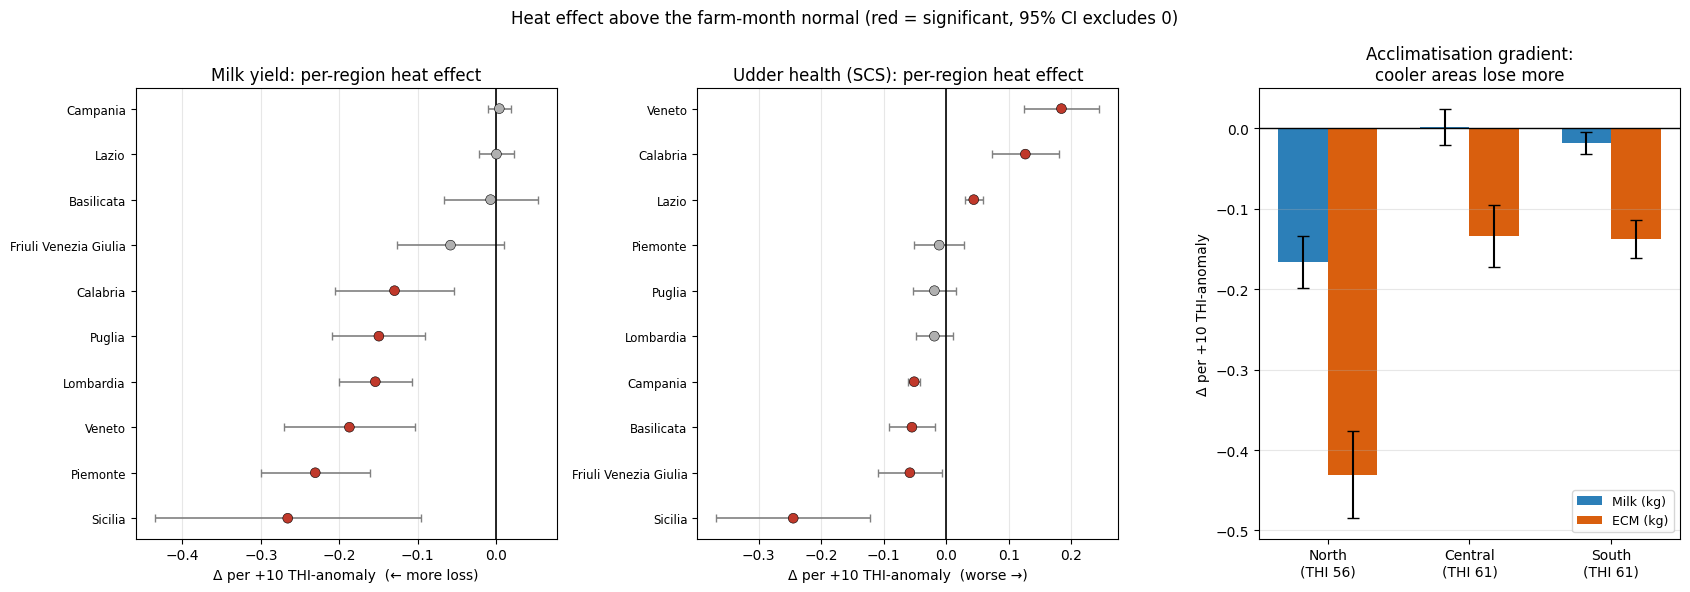

In [109]:
# --- Visualize: per-region forest plots + macro-area acclimatisation gradient ---
# Reuses fe_effect_cluster, reliable_regions, MACRO_AREA, sc, THI_COL.
sc['Area'] = sc['Region'].map(MACRO_AREA)

# Per-region slope + SE for the two headline traits
prg = []
for region in reliable_regions:
    sub = sc[sc['Region'] == region]
    row = {'Region': region}
    for v in ['milk_kg', 'SCS']:
        b, se, p, n, G = fe_effect_cluster(sub, v)
        row[v], row[v + '_se'] = b, se
    prg.append(row)
prg = pd.DataFrame(prg)

# Macro-area pooled slopes (high power) for milk and ECM
areas = ['North', 'Central', 'South']
area_stat = {}
for a in areas:
    sub = sc[sc['Area'] == a]
    area_stat[a] = {'thi': sub[THI_COL].mean()}
    for v in ['milk_kg', 'ECM']:
        b, se, p, n, G = fe_effect_cluster(sub, v)
        area_stat[a][v], area_stat[a][v + '_se'] = b, se

fig, ax = plt.subplots(1, 3, figsize=(17, 6))

def forest(a, v, title, arrow):
    d = prg.sort_values(v)
    y = np.arange(len(d))
    err = 1.96 * d[v + '_se']
    sig = (d[v] - err > 0) | (d[v] + err < 0)
    colors = ['#c0392b' if s else '#b0b0b0' for s in sig]
    a.errorbar(d[v], y, xerr=err, fmt='none', ecolor='gray', elinewidth=1.2, capsize=3)
    a.scatter(d[v], y, color=colors, s=50, zorder=3, edgecolor='k', lw=0.4)
    a.axvline(0, color='k', lw=1.2)
    a.set_yticks(y); a.set_yticklabels(d['Region'], fontsize=8.5)
    a.set_title(title); a.set_xlabel(f'Δ per +10 THI-anomaly  ({arrow})')
    a.grid(alpha=0.3, axis='x')

forest(ax[0], 'milk_kg', 'Milk yield: per-region heat effect', '← more loss')
forest(ax[1], 'SCS', 'Udder health (SCS): per-region heat effect', 'worse →')

xa = np.arange(3); w = 0.35
ax[2].bar(xa - w/2, [area_stat[a]['milk_kg'] for a in areas], w,
          yerr=[1.96 * area_stat[a]['milk_kg_se'] for a in areas], capsize=4,
          color='#2c7fb8', label='Milk (kg)')
ax[2].bar(xa + w/2, [area_stat[a]['ECM'] for a in areas], w,
          yerr=[1.96 * area_stat[a]['ECM_se'] for a in areas], capsize=4,
          color='#d95f0e', label='ECM (kg)')
ax[2].axhline(0, color='k', lw=1)
ax[2].set_xticks(xa)
ax[2].set_xticklabels([f'{a}\n(THI {area_stat[a]["thi"]:.0f})' for a in areas])
ax[2].set_ylabel('Δ per +10 THI-anomaly')
ax[2].set_title('Acclimatisation gradient:\ncooler areas lose more')
ax[2].legend(fontsize=9); ax[2].grid(alpha=0.3, axis='y')

fig.suptitle('Heat effect above the farm-month normal '
             '(red = significant, 95% CI excludes 0)', fontsize=12)
fig.tight_layout()
plt.show()


---
## Headline split: Campania + Lazio vs the Rest (cluster-curve + parity controlled)

Campania and Lazio are the two **largest** regions and both show ~0 milk response to heat — together they are the buffalo mozzarella-DOP heartland and ~85% of the records. Pooling them into a single "non-Campania" group earlier let Lazio dilute the loss seen in the smaller regions. So here we split into:

- **Campania + Lazio** — the large DOP-heartland core,
- **Rest** — all other (mostly smaller, more northern/peripheral) herds,

using the same cluster-curve + parity control. This makes the contrast honest: the heartland is heat-insensitive for milk, while the rest carries the real loss.


Heat effect per +10 THI-anomaly — cluster-curve + parity controlled
(milk/ECM negative = worse; SCS positive = worse; *** p<.001 ** p<.01 * p<.05 ns)

                  n_animals    milk_kg        ECM        SCS
group                                                       
Campania + Lazio      74889   +0.001ns  -0.118***  -0.023***
Rest                  15662  -0.142***  -0.364***   -0.001ns
ALL                   90532  -0.032***  -0.175***  -0.018***


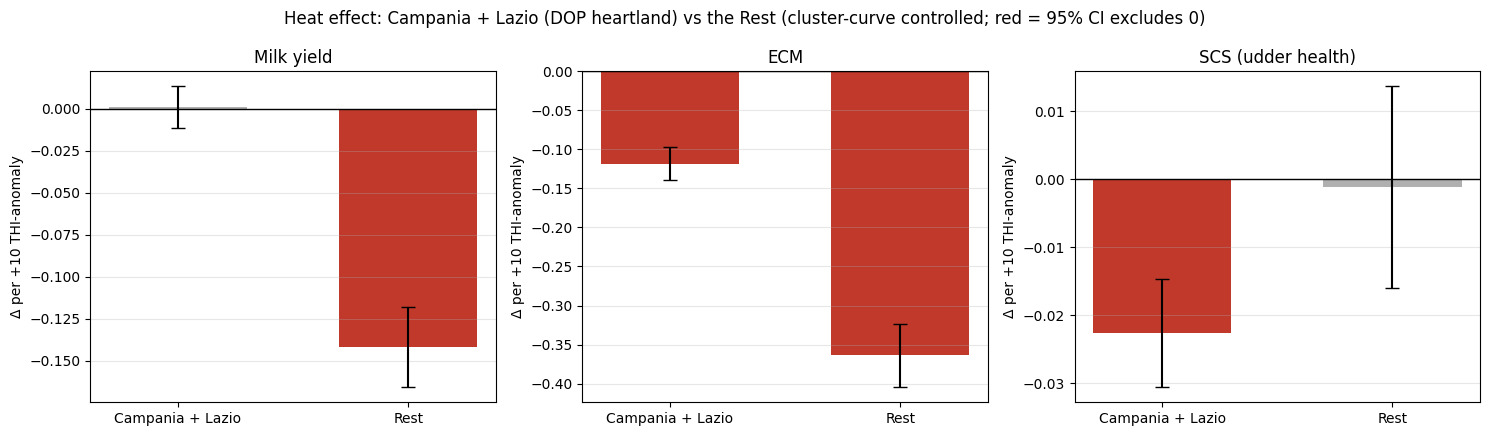

In [110]:
# --- Campania + Lazio vs Rest, cluster-curve controlled (table + figure) ---
# Reuses sc (with cc_wa etc.) and fe_effect_cluster from the metric cell above.
def stars(p):
    return '' if not np.isfinite(p) else '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'ns'

CORE = ['Campania', 'Lazio']          # the two large ~0-effect DOP-heartland regions
split_groups = [('Campania + Lazio', sc[sc['Region'].isin(CORE)]),
                ('Rest',             sc[~sc['Region'].isin(CORE)]),
                ('ALL',              sc)]
head_traits = ['milk_kg', 'ECM', 'SCS']

rows, est = [], {}
for gname, gsub in split_groups:
    row = {'group': gname, 'n_animals': gsub['Animal_ID'].nunique()}
    for v in head_traits:
        b, se, p, n, G = fe_effect_cluster(gsub, v)
        row[v] = f'{b:+.3f}{stars(p)}'
        est[(gname, v)] = (b, se)
    rows.append(row)
split_tbl = pd.DataFrame(rows).set_index('group')
print('Heat effect per +10 THI-anomaly — cluster-curve + parity controlled')
print('(milk/ECM negative = worse; SCS positive = worse; *** p<.001 ** p<.01 * p<.05 ns)\n')
print(split_tbl.to_string())

# Figure: Campania+Lazio vs Rest, one panel per trait, 95% CI
plot_groups = ['Campania + Lazio', 'Rest']
titles = {'milk_kg': 'Milk yield', 'ECM': 'ECM', 'SCS': 'SCS (udder health)'}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, v in zip(axes, head_traits):
    xs = np.arange(len(plot_groups))
    vals = [est[(g, v)][0] for g in plot_groups]
    errs = [1.96 * est[(g, v)][1] for g in plot_groups]
    colors = ['#c0392b' if abs(b) > e else '#b0b0b0' for b, e in zip(vals, errs)]
    ax.bar(xs, vals, 0.6, yerr=errs, capsize=5, color=colors)
    ax.axhline(0, color='k', lw=1)
    ax.set_xticks(xs); ax.set_xticklabels(plot_groups)
    ax.set_title(titles[v]); ax.set_ylabel('Δ per +10 THI-anomaly'); ax.grid(alpha=0.3, axis='y')
fig.suptitle('Heat effect: Campania + Lazio (DOP heartland) vs the Rest '
             '(cluster-curve controlled; red = 95% CI excludes 0)', fontsize=12)
fig.tight_layout()
plt.show()


---
## Diagnostic: does the lactation-curve control hide the THI effect?

A fair worry: could controlling for the lactation curve **absorb** the heat signal and hide it? Two checks:

1. **Correlation.** A control can only steal a regressor's effect to the extent the two are correlated. If `thi_anom` and the cluster curve `cc` are near-orthogonal, `cc` *cannot* stand in for heat.
2. **Before/after the control.** Compare the milk heat effect with **no lactation control** vs **with the cluster curve**. If the effect stays strongly significant, the curve is de-confounding (removing lactation-timing overlap), not hiding.


In [111]:
# --- Diagnostic: is the cluster curve absorbing the THI effect? ---
# Reuses sc (thi_anom_wa, cc_wa, milk_kg_wa, parity_wa), CORE, and math erf/sqrt.
sc['DIM_wa'] = sc['DIM'] - sc.groupby('Animal_ID')['DIM'].transform('mean')

r_cc  = np.corrcoef(sc['thi_anom_wa'], sc['cc_wa'])[0, 1]
r_dim = np.corrcoef(sc['thi_anom_wa'], sc['DIM_wa'])[0, 1]
print('(1) Within-animal correlation of THI-anomaly with the lactation controls:')
print(f'      corr(thi_anom, cc)  = {r_cc:+.3f}')
print(f'      corr(thi_anom, DIM) = {r_dim:+.3f}')
print('    -> ~0: the curve is almost orthogonal to heat, so it cannot stand in for it.\n')

def milk_heat(frame, controls, scale=10):
    """Within-animal milk heat effect under a given control set; animal-clustered SE."""
    d = frame[['thi_anom_wa', 'milk_kg_wa'] + controls + ['Animal_ID']].dropna()
    X = d[['thi_anom_wa'] + controls].values
    y = d['milk_kg_wa'].values
    beta = np.linalg.solve(X.T @ X, X.T @ y)
    Inv = np.linalg.inv(X.T @ X)
    resid = y - X @ beta
    S = pd.DataFrame(X * resid[:, None]).groupby(d['Animal_ID'].values).sum().values
    V = Inv @ (S.T @ S) @ Inv
    b, se = beta[0], sqrt(V[0, 0]); t = b / se
    return b * scale, 2 * (1 - 0.5 * (1 + erf(abs(t) / sqrt(2))))

def stars_d(p):
    return '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'ns'

print('(2) Milk effect per +10 THI-anomaly — NO lactation control vs cluster curve:')
diag_groups = [('Campania + Lazio', sc[sc['Region'].isin(CORE)]),
               ('Rest',             sc[~sc['Region'].isin(CORE)]),
               ('ALL',              sc)]
for gname, g in diag_groups:
    b0, p0 = milk_heat(g, ['parity_wa'])                 # no lactation control
    b1, p1 = milk_heat(g, ['cc_wa', 'parity_wa'])        # + cluster curve
    print(f'      {gname:16s}  no-curve {b0:+.3f}{stars_d(p0):<3s}   '
          f'+cluster-curve {b1:+.3f}{stars_d(p1):<3s}   (change {b1 - b0:+.3f})')

print('\nThe effect shrinks a little (removes lactation-timing confounding) but stays')
print('strongly significant -> the curve DE-CONFOUNDS, it does not hide the heat effect.')


(1) Within-animal correlation of THI-anomaly with the lactation controls:
      corr(thi_anom, cc)  = -0.003
      corr(thi_anom, DIM) = +0.005
    -> ~0: the curve is almost orthogonal to heat, so it cannot stand in for it.

(2) Milk effect per +10 THI-anomaly — NO lactation control vs cluster curve:
      Campania + Lazio  no-curve -0.070***   +cluster-curve +0.001ns    (change +0.070)
      Rest              no-curve -0.213***   +cluster-curve -0.142***   (change +0.071)
      ALL               no-curve -0.103***   +cluster-curve -0.032***   (change +0.070)

The effect shrinks a little (removes lactation-timing confounding) but stays
strongly significant -> the curve DE-CONFOUNDS, it does not hide the heat effect.
